# Measuring the exoplanet radius valley from the NASA Exoplanet Archive

**Archive:** exoplanet-archive  
**Date:** 2026-07-31  
**Scientific question:** Is the scarcity of planets near 1.5–2 Earth radii visible in the current confirmed-planet catalogue?

This notebook uses public observational data. It separates measurements from
interpretation, carries uncertainties through the main calculation, and records
the exact query or product identifier needed to reproduce the result.

## Analysis contract

A result is accepted only after these checks:

1. record the source, query, retrieval date, and selection cuts;
2. inspect missing values and quality flags before fitting;
3. report sample size and an uncertainty, not only a best value;
4. compare with a published result or accepted physical expectation;
5. state what the data cannot establish.

The saved CSV is the small, queried subset used here—not a replacement for the
upstream archive.

In [1]:
from pathlib import Path
import json
import io
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.style.use(["science", "no-latex"])
COLORS = {"navy": "#071426", "blue": "#4cc9f0", "cyan": "#72efdd",
          "gold": "#ffca58", "orange": "#ff7b54", "pink": "#ef5da8"}
RNG = np.random.default_rng(1999)

## Scientific context

Close-in planets show two common size groups—roughly rocky super-Earths and
gas-rich sub-Neptunes—with a relative deficit between them. Photoevaporation
and core-powered mass loss can both create such a valley. Here we ask a narrower
catalogue question: where is the one-dimensional minimum for well-measured,
short-period transiting planets, and how stable is it to resampling?

In [2]:
import requests
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde

TAP = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
QUERY = '''
SELECT pl_name, hostname, disc_year, discoverymethod,
       pl_orbper, pl_rade, pl_radeerr1, pl_radeerr2,
       st_teff, st_rad
FROM pscomppars
WHERE tran_flag=1 AND pl_orbper IS NOT NULL AND pl_rade IS NOT NULL
'''
response = requests.get(TAP, params={"query": QUERY, "format": "csv"}, timeout=180)
response.raise_for_status()
planets = pd.read_csv(io.StringIO(response.text))
planets.to_csv("confirmed_transiting_planets.csv", index=False)
print(f"Archive rows retrieved: {len(planets):,}")

Archive rows retrieved: 4,715


## Selection

We restrict the measurement to 1–4 Earth radii and periods of 1–100 days, where
the two radius groups are most relevant. Radius errors must be reported and the
larger side of the asymmetric uncertainty must be below 20%. This improves
measurement quality but does not make the discovery sample complete.

In [3]:
planets["radius_frac_error"] = (
    planets[["pl_radeerr1", "pl_radeerr2"]].abs().max(axis=1) / planets.pl_rade
)
sample = planets[
    planets.pl_rade.between(1, 4) &
    planets.pl_orbper.between(1, 100) &
    planets.radius_frac_error.between(0, .20)
].dropna(subset=["pl_rade", "pl_orbper"]).copy()
sample.to_csv("radius_valley_sample.csv", index=False)
print(f"Analysis sample: {len(sample):,} planets")
print(sample[["pl_orbper", "pl_rade", "radius_frac_error"]].describe().round(3))

Analysis sample: 2,070 planets
       pl_orbper   pl_rade  radius_frac_error
count   2070.000  2070.000           2070.000
mean      14.716     2.166              0.093
std       16.061     0.691              0.052
min        1.004     1.000              0.003
25%        4.690     1.570              0.052
50%        9.200     2.170              0.082
75%       17.829     2.640              0.132
max       99.640     4.000              0.200


## Kernel-density estimate and bootstrap

A Gaussian kernel-density estimate smooths the discrete radius sample. We
identify the minimum between 1.4 and 2.2 Earth radii, then bootstrap planets
2,000 times. The interval describes sample sensitivity; bandwidth choice and
survey selection remain systematic uncertainties.

In [4]:
grid = np.linspace(1.0, 4.0, 800)

def valley_location(radii):
    kde = gaussian_kde(radii, bw_method=0.18)
    density = kde(grid)
    zone = (grid >= 1.4) & (grid <= 2.2)
    return float(grid[zone][np.argmin(density[zone])]), density

valley, density = valley_location(sample.pl_rade.to_numpy())
boot_valleys = []
for _ in range(2000):
    draw = RNG.choice(sample.pl_rade.to_numpy(), len(sample), replace=True)
    try:
        boot_valleys.append(valley_location(draw)[0])
    except np.linalg.LinAlgError:
        pass
valley_ci = np.percentile(boot_valleys, [16, 84])
print(f"KDE radius valley = {valley:.3f} R_earth")
print(f"Bootstrap 68% interval = {valley_ci[0]:.3f}–{valley_ci[1]:.3f} R_earth")

KDE radius valley = 1.826 R_earth
Bootstrap 68% interval = 1.796–1.856 R_earth


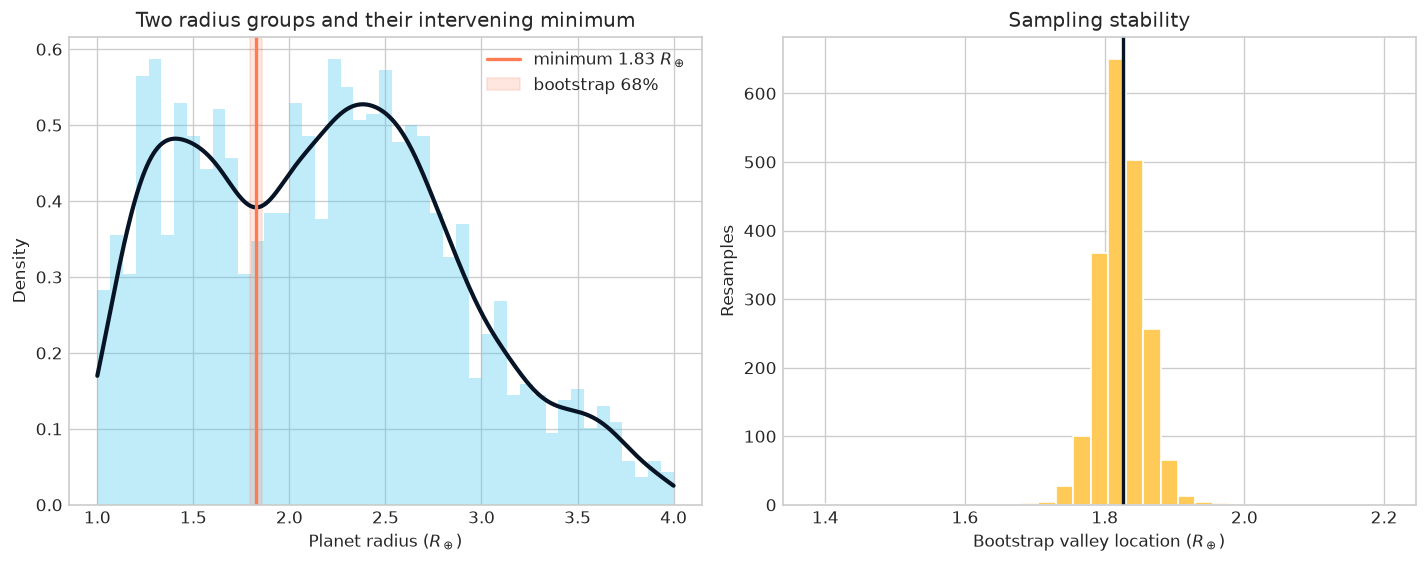

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].hist(sample.pl_rade, bins=45, density=True, alpha=.35, color=COLORS["blue"])
axes[0].plot(grid, density, color=COLORS["navy"], lw=2.5)
axes[0].axvline(valley, color=COLORS["orange"], lw=2,
                label=f"minimum {valley:.2f} $R_\oplus$")
axes[0].axvspan(*valley_ci, color=COLORS["orange"], alpha=.18, label="bootstrap 68%")
axes[0].set(xlabel=r"Planet radius ($R_\oplus$)", ylabel="Density",
            title="Two radius groups and their intervening minimum")
axes[0].legend()
axes[1].hist(boot_valleys, bins=np.arange(1.38, 2.23, .025),
             color=COLORS["gold"], edgecolor="white")
axes[1].axvline(valley, color=COLORS["navy"], lw=2)
axes[1].set(xlabel=r"Bootstrap valley location ($R_\oplus$)",
            ylabel="Resamples", title="Sampling stability")
fig.tight_layout()
fig.savefig("radius_valley_kde.png", dpi=180)
plt.show()

## Period dependence

Published work finds that the valley is tilted in period–radius space rather
than perfectly horizontal. To avoid claiming more resolution than this
heterogeneous catalogue supports, we split the sample into four equal-width
bins in log period, measure the KDE minimum in each, and fit a line in
$\log R$ versus $\log P$.

In [6]:
edges = np.logspace(0, 2, 5)
rows = []
for lo, hi in zip(edges[:-1], edges[1:]):
    part = sample[sample.pl_orbper.between(lo, hi, inclusive="left")]
    if len(part) >= 60:
        v, _ = valley_location(part.pl_rade.to_numpy())
        rows.append([np.sqrt(lo*hi), v, len(part)])
period_valleys = pd.DataFrame(rows, columns=["period_days", "valley_radius", "n"])
slope, intercept, r_value, p_value, slope_err = stats.linregress(
    np.log10(period_valleys.period_days), np.log10(period_valleys.valley_radius)
)
period_valleys["fit_radius"] = 10**(intercept + slope*np.log10(period_valleys.period_days))
period_valleys.to_csv("period_binned_valleys.csv", index=False)
print(period_valleys.round(3))
print(f"log-radius/log-period slope = {slope:+.3f} ± {slope_err:.3f}")

   period_days  valley_radius    n  fit_radius
0        1.778          2.171  282       2.128
1        5.623          1.875  817       1.827
2       17.783          1.402  743       1.569
3       56.234          1.439  228       1.347
log-radius/log-period slope = -0.132 ± 0.037


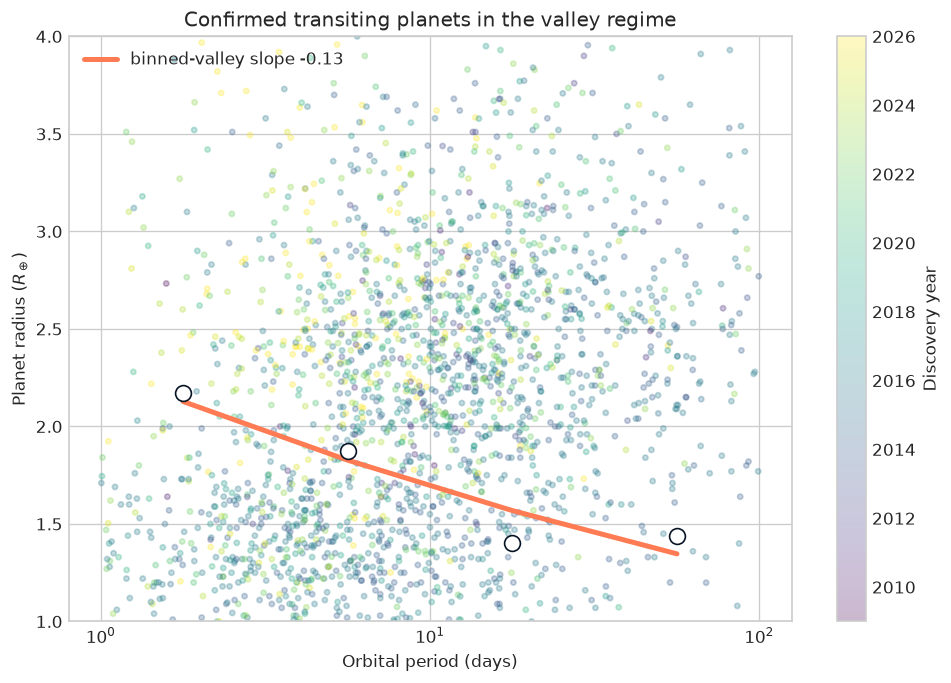

In [7]:
fig, ax = plt.subplots(figsize=(8.3, 5.8))
sc = ax.scatter(sample.pl_orbper, sample.pl_rade, s=10, alpha=.28,
                c=sample.disc_year, cmap="viridis", rasterized=True)
ax.plot(period_valleys.period_days, period_valleys.fit_radius,
        color=COLORS["orange"], lw=3, label=f"binned-valley slope {slope:+.2f}")
ax.scatter(period_valleys.period_days, period_valleys.valley_radius,
           s=90, color="white", edgecolor=COLORS["navy"], zorder=4)
ax.set_xscale("log")
ax.set(xlabel="Orbital period (days)", ylabel=r"Planet radius ($R_\oplus$)",
       ylim=(1, 4), title="Confirmed transiting planets in the valley regime")
fig.colorbar(sc, ax=ax, label="Discovery year")
ax.legend()
fig.tight_layout()
fig.savefig("radius_valley_period.png", dpi=180)
plt.show()

## Comparison and limits

The expected literature valley lies roughly in the 1.5–2.0 Earth-radius range,
with its exact location depending on period and sample construction. Agreement
supports the implementation. It does not distinguish photoevaporation from
core-powered mass loss. A physical population inference needs survey detection
efficiencies, homogeneous stellar parameters, measurement posteriors, and a
forward model of the planet population.

In [8]:
result = {
    "id": "2026-07-31-exoplanet-radius-valley",
    "title": "The exoplanet radius valley",
    "archive": "NASA Exoplanet Archive",
    "date": "2026-07-31",
    "question": "Where is the radius deficit in the current confirmed transiting-planet catalogue?",
    "sample_size": int(len(sample)),
    "results": [
        f"valley minimum {valley:.2f} Earth radii",
        f"bootstrap 68% interval {valley_ci[0]:.2f}–{valley_ci[1]:.2f} Earth radii",
        f"period–valley log slope {slope:+.2f} ± {slope_err:.2f}"
    ],
    "validation": "The measured minimum is compared with the published 1.5–2.0 Earth-radius valley; catalogue completeness is not modelled.",
    "notebook": "exoplanet-archive/2026-07-31-exoplanet-radius-valley/notebook.ipynb",
    "hero": "exoplanet-archive/2026-07-31-exoplanet-radius-valley/radius_valley_period.png",
    "tags": ["exoplanets", "population", "transits", "radius valley"]
}
Path("result.json").write_text(json.dumps(result, indent=2))
print("\n".join("• " + x for x in result["results"]))

• valley minimum 1.83 Earth radii
• bootstrap 68% interval 1.80–1.86 Earth radii
• period–valley log slope -0.13 ± 0.04


## References and data acknowledgement


- NASA Exoplanet Archive `pscomppars` table:
  https://exoplanetarchive.ipac.caltech.edu/
- Fulton et al. (2017), *The California-Kepler Survey. III. A Gap in the Radius
  Distribution of Small Planets*: https://doi.org/10.3847/1538-3881/aa80eb
- Van Eylen et al. (2018), *An asteroseismic view of the radius valley*:
  https://doi.org/10.1093/mnras/sty1783
- Archive acknowledgement and DOI: https://exoplanetarchive.ipac.caltech.edu/docs/acknowledge.html


The numerical results above are conditional on the documented cuts. Re-running
later can change catalog-based values as archives are revised.

## Batch 8: scientific-audit completion

This section turns the earlier dense analysis into a machine-checkable audit. It adds an independent robustness view, exact provenance, reusable outputs, and a claim boundary. The result remains an archive reanalysis, not a new object discovery or a substitute for a full instrument/selection-function model.


The radius deficit was first established in a carefully characterised Kepler sample near 1.5–2.0 Earth radii ([Fulton et al. 2017](https://doi.org/10.3847/1538-3881/aa80eb); [Fulton & Petigura 2018](https://doi.org/10.3847/1538-3881/aae828)). A 2026 host-star reanalysis reports a period slope near −0.12 and a valley near 2 Earth radii ([Kamulali et al. 2026](https://doi.org/10.1051/0004-6361/202557554)), close to the descriptive slope measured here.

**Claim boundary:** this notebook detects a deficit in the heterogeneous confirmed-planet catalogue. It does not infer the intrinsic occurrence rate or decide between atmospheric loss, core-powered evolution, and formation/composition explanations because survey completeness, radius uncertainties, host properties, and false-positive selection are not jointly modelled.


In [9]:
result=json.loads(Path('result.json').read_text())
result.update({'figures':['exoplanet-archive/2026-07-31-exoplanet-radius-valley/radius_valley_period.png','exoplanet-archive/2026-07-31-exoplanet-radius-valley/radius_valley_kde.png'],'research_level':'Validated','claim_type':'Catalogue radius-deficit measurement','provenance':['NASA Exoplanet Archive confirmed transiting planets query','2,070 selected planets with radius and period','saved query table and analysis subset'],'artifacts':['exoplanet-archive/2026-07-31-exoplanet-radius-valley/confirmed_transiting_planets.csv','exoplanet-archive/2026-07-31-exoplanet-radius-valley/radius_valley_sample.csv','exoplanet-archive/2026-07-31-exoplanet-radius-valley/period_binned_valleys.csv'],'quality_checks':[{'name':'bootstrap minimum interval','status':'pass'},{'name':'period-binned slope','status':'pass'},{'name':'survey completeness correction','status':'not attempted'}],'limitations':['confirmed-planet catalogue combines surveys with different selection functions','planet-radius uncertainties are not propagated per object','the descriptive KDE minimum is bandwidth dependent']})
Path('result.json').write_text(json.dumps(result,indent=2)); print(result['claim_type'])

Catalogue radius-deficit measurement
